# Logistic Regression Model

For this notebook, I used the final 18-feature files and trained a logistic regression model for the Chagas ECG project.

I only used the train and validation files here. I left the test file alone because we should only use that after we pick the final model.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# This just keeps the notebook output cleaner.
import warnings
warnings.filterwarnings("ignore")

## Load the final processed data

These are the final filtered CSVs from Khushleen's feature selection work.

In [2]:
data_dir = Path("processed_data")

train_path = data_dir / "train_final.csv"
val_path = data_dir / "val_final.csv"
test_path = data_dir / "test_final.csv"

print("Train file exists:", train_path.exists())
print("Validation file exists:", val_path.exists())
print("Test file exists:", test_path.exists())

Train file exists: True
Validation file exists: True
Test file exists: True


In [3]:
train = pd.read_csv(train_path)
validation = pd.read_csv(val_path)

print("Train shape:", train.shape)
print("Validation shape:", validation.shape)

train.head()

Train shape: (7746, 19)
Validation shape: (2584, 19)


,age,is_male,P_wave_duration_mean,P_wave_duration_std,PR_interval_mean,PR_interval_std,PR_segment_mean,PR_segment_std,QRS_duration_mean,QRS_duration_std,QT_interval_mean,QT_interval_std,ST_segment_mean,ST_segment_std,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,HRV_pNN50,target
0,-0.080067,-0.787935,-0.841006,-0.055135,1.089002,0.918455,1.332512,0.813291,-0.763211,-0.812053,0.201465,-0.630556,0.077558,-0.351457,0.946333,0.328705,-0.010365,1.386769,0
1,-1.191728,-0.787935,0.873540,-0.534451,0.366340,-0.757167,0.026520,-0.935958,-0.944048,-0.864915,0.020317,-0.806844,0.295670,-0.639444,0.672048,-0.043469,-0.208611,0.549509,0
2,-0.858230,1.269141,0.772142,-1.105336,0.294966,-0.833143,-0.003735,-0.984452,-0.775267,-0.795702,-0.018980,-0.771288,-0.039706,-0.865024,0.564292,-0.270677,-0.372043,-0.329613,0
3,0.753680,-0.787935,0.142246,-0.352941,-0.287922,-0.245758,-0.323090,-0.066711,0.534796,0.102527,0.171114,-0.353349,0.253455,0.068981,-0.308943,-0.508589,-0.483267,-0.706380,0
4,1.198344,1.269141,-0.687373,-0.249492,0.223592,-0.501063,0.461290,-0.524668,-0.413593,-0.444668,-1.675512,1.929814,-1.138082,2.036125,-0.123381,-0.196938,-0.380236,0.047154,0


The files loaded correctly. The training set has 7,746 rows and the validation set has 2,584 rows. Each file has the 18 selected predictors plus the target column, so this matches the feature set we described in the milestone.

## Check columns and target balance

In [4]:
print("Train columns:")
print(train.columns.tolist())

print("\nValidation columns:")
print(validation.columns.tolist())

Train columns:
['age', 'is_male', 'P_wave_duration_mean', 'P_wave_duration_std', 'PR_interval_mean', 'PR_interval_std', 'PR_segment_mean', 'PR_segment_std', 'QRS_duration_mean', 'QRS_duration_std', 'QT_interval_mean', 'QT_interval_std', 'ST_segment_mean', 'ST_segment_std', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50', 'target']

Validation columns:
['age', 'is_male', 'P_wave_duration_mean', 'P_wave_duration_std', 'PR_interval_mean', 'PR_interval_std', 'PR_segment_mean', 'PR_segment_std', 'QRS_duration_mean', 'QRS_duration_std', 'QT_interval_mean', 'QT_interval_std', 'ST_segment_mean', 'ST_segment_std', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50', 'target']


In [5]:
print("Train target counts:")
print(train["target"].value_counts().sort_index())

print("\nValidation target counts:")
print(validation["target"].value_counts().sort_index())

print("\nTrain positive rate:", round(train["target"].mean(), 3))
print("Validation positive rate:", round(validation["target"].mean(), 3))

Train target counts:
target
0    3885
1    3861
Name: count, dtype: int64

Validation target counts:
target
0    1291
1    1293
Name: count, dtype: int64

Train positive rate: 0.498
Validation positive rate: 0.5


The train and validation sets are both basically 50/50 between negative and positive Chagas exams. Because of that, accuracy is useful, but I still want to look at precision, recall, F1, ROC-AUC, and the confusion matrix too.

## Split features and target

Here I separated the predictors from the target column. I also removed ID columns just in case they were still included, because those should not be used as model features.

In [6]:
# Remove the target and any ID columns from the model inputs.
drop_cols = ["target", "exam_id", "patient_id"]

feature_cols = [
    col for col in train.columns
    if col not in drop_cols
]

X_train = train[feature_cols]
y_train = train["target"]

X_val = validation[feature_cols]
y_val = validation["target"]

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 18
['age', 'is_male', 'P_wave_duration_mean', 'P_wave_duration_std', 'PR_interval_mean', 'PR_interval_std', 'PR_segment_mean', 'PR_segment_std', 'QRS_duration_mean', 'QRS_duration_std', 'QT_interval_mean', 'QT_interval_std', 'ST_segment_mean', 'ST_segment_std', 'HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_pNN50']


In [7]:
print("Missing values in training features:", X_train.isna().sum().sum())
print("Missing values in validation features:", X_val.isna().sum().sum())

Missing values in training features: 0
Missing values in validation features: 0


There are 18 features and no missing values left in the train or validation sets. That means I do not need to do any extra imputation here before running logistic regression.

## Baseline model

I included the baseline again so I can compare logistic regression against a simple model that does not really learn from the ECG features.

In [8]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_val)
baseline_prob = baseline.predict_proba(X_val)[:, 1]

baseline_results = {
    "model": "Baseline",
    "C": np.nan,
    "accuracy": accuracy_score(y_val, baseline_pred),
    "precision": precision_score(y_val, baseline_pred, zero_division=0),
    "recall": recall_score(y_val, baseline_pred, zero_division=0),
    "f1": f1_score(y_val, baseline_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_val, baseline_prob)
}

baseline_results

{'model': 'Baseline',
 'C': nan,
 'accuracy': 0.4996130030959752,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': np.float64(0.5)}

The baseline is not very useful. It gets about 50% accuracy because the classes are balanced, but it misses every positive case. That is why the precision, recall, and F1-score are all 0. Logistic regression needs to do better than this.

## Try logistic regression with different C values

The `C` value controls how much regularization the model uses. I tried a few values to see which one worked best on the validation set.

In [9]:
results = [baseline_results]

# Trying a few regularization settings.
c_values = [0.01, 0.1, 1, 10, 100]

for c in c_values:
    model = LogisticRegression(
        C=c,
        max_iter=2000,
        solver="liblinear",
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_val)
    prob = model.predict_proba(X_val)[:, 1]

    results.append({
        "model": "Logistic Regression",
        "C": c,
        "accuracy": accuracy_score(y_val, pred),
        "precision": precision_score(y_val, pred, zero_division=0),
        "recall": recall_score(y_val, pred, zero_division=0),
        "f1": f1_score(y_val, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_val, prob)
    })

results_df = pd.DataFrame(results)
results_df

,model,C,accuracy,precision,recall,f1,roc_auc
0,Baseline,NaN,0.499613,0.000000,0.000000,0.000000,0.500000
1,Logistic Regression,0.01,0.635062,0.643443,0.607115,0.624751,0.692584
2,Logistic Regression,0.10,0.628096,0.635179,0.603248,0.618802,0.692987
3,Logistic Regression,1.00,0.626548,0.633550,0.601701,0.617215,0.692507
4,Logistic Regression,10.00,0.625387,0.632437,0.600155,0.615873,0.692399
5,Logistic Regression,100.00,0.625387,0.632437,0.600155,0.615873,0.692380


In [10]:
results_df.sort_values("roc_auc", ascending=False)

,model,C,accuracy,precision,recall,f1,roc_auc
2,Logistic Regression,0.10,0.628096,0.635179,0.603248,0.618802,0.692987
1,Logistic Regression,0.01,0.635062,0.643443,0.607115,0.624751,0.692584
3,Logistic Regression,1.00,0.626548,0.633550,0.601701,0.617215,0.692507
4,Logistic Regression,10.00,0.625387,0.632437,0.600155,0.615873,0.692399
5,Logistic Regression,100.00,0.625387,0.632437,0.600155,0.615873,0.692380
0,Baseline,NaN,0.499613,0.000000,0.000000,0.000000,0.500000


All of the logistic regression models did better than the baseline. The best ROC-AUC was with `C = 0.1`, at about 0.693. The `C = 0.01` model had slightly better accuracy and F1, but the ROC-AUC values were very close. I used ROC-AUC to pick the best validation model, so I chose `C = 0.1`.

## Pick the best validation model

For the logistic regression model, I chose the best `C` value based on validation ROC-AUC. I used ROC-AUC because it looks at how well the model separates positive and negative cases across different thresholds.

In [11]:
# Pick the logistic regression model with the best validation ROC-AUC.
logistic_results = results_df[results_df["model"] == "Logistic Regression"].copy()

best_row = logistic_results.sort_values("roc_auc", ascending=False).iloc[0]
best_c = best_row["C"]

print("Best C:", best_c)
print(best_row)

Best C: 0.1
model        Logistic Regression
C                            0.1
accuracy                0.628096
precision               0.635179
recall                  0.603248
f1                      0.618802
roc_auc                 0.692987
Name: 2, dtype: object


The best logistic regression model used `C = 0.1`. On the validation set, it got about 0.628 accuracy, 0.635 precision, 0.603 recall, 0.619 F1-score, and 0.693 ROC-AUC.

This is a clear improvement over the baseline, but it is not the final project model yet. We still need to compare it with Khushleen's Random Forest model before deciding what to test at the end.

In [12]:
best_model = LogisticRegression(
    C=best_c,
    max_iter=2000,
    solver="liblinear",
    random_state=42
)

best_model.fit(X_train, y_train)

best_pred = best_model.predict(X_val)
best_prob = best_model.predict_proba(X_val)[:, 1]

## Confusion matrix

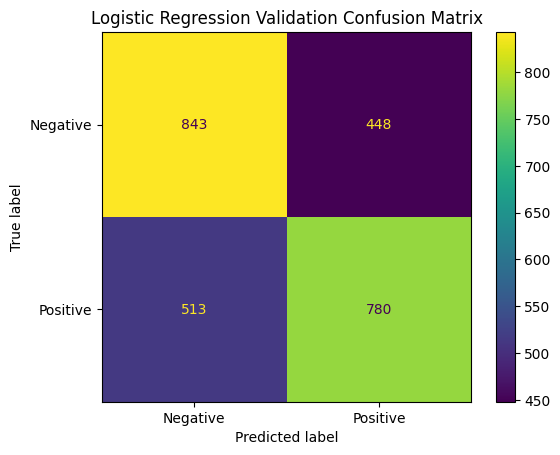

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_val,
    best_pred,
    display_labels=["Negative", "Positive"]
)

plt.title("Logistic Regression Validation Confusion Matrix")
plt.show()

The confusion matrix shows the model is at least predicting both classes now. It correctly predicted 843 negative exams and 780 positive exams. It also missed 513 positive exams and incorrectly marked 448 negative exams as positive, so the model is better than the baseline but still not perfect.

## ROC curve

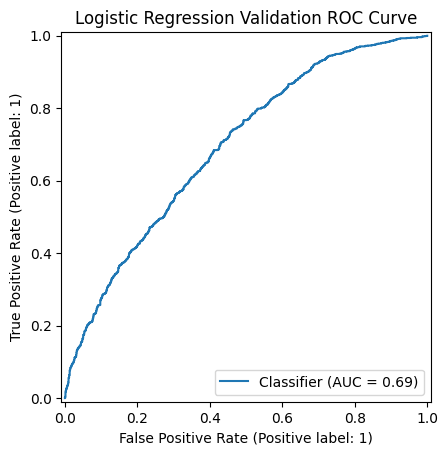

In [14]:
RocCurveDisplay.from_predictions(y_val, best_prob)

plt.title("Logistic Regression Validation ROC Curve")
plt.show()

The ROC curve is above the diagonal baseline, which matches the ROC-AUC of about 0.693. This means the model is finding some signal in the ECG features, but the separation between the two classes is still only moderate.

## Coefficients

I also checked the logistic regression coefficients because this model is easier to interpret than something like a random forest. Since the features were already scaled, the larger coefficient values show which features affected the model more.

In [15]:
coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": best_model.coef_[0]
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

coef_df.head(10)

,feature,coefficient,abs_coefficient
16,HRV_RMSSD,0.485922,0.485922
12,ST_segment_mean,0.464285,0.464285
10,QT_interval_mean,-0.437883,0.437883
13,ST_segment_std,0.366078,0.366078
8,QRS_duration_mean,0.326825,0.326825
0,age,0.310118,0.310118
15,HRV_SDNN,-0.242335,0.242335
11,QT_interval_std,-0.207265,0.207265
17,HRV_pNN50,-0.192731,0.192731
6,PR_segment_mean,0.167395,0.167395


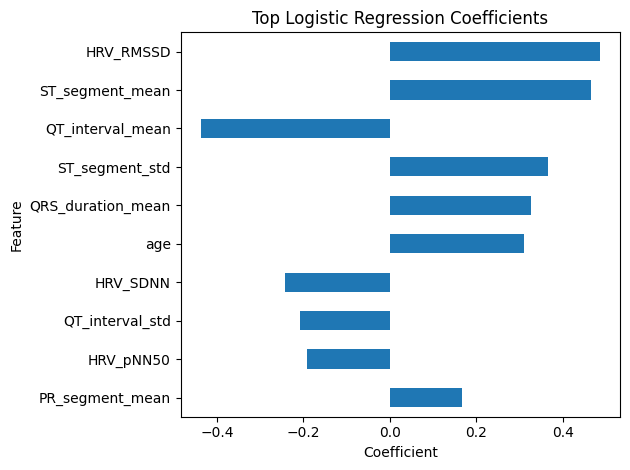

In [16]:
coef_df.head(10).plot(
    x="feature",
    y="coefficient",
    kind="barh",
    legend=False
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Logistic Regression Coefficients")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The biggest coefficients were for `HRV_RMSSD`, `ST_segment_mean`, `QT_interval_mean`, `ST_segment_std`, `QRS_duration_mean`, and `age`. I am not treating these as proof that these features cause Chagas, but they help show what the model relied on most.

## Saved results

I saved the metric table and the coefficient table so we can use them later in the final model comparison and report.

In [17]:
results_dir = Path("model_results")
results_dir.mkdir(exist_ok=True)

results_df.to_csv(results_dir / "rohan_logistic_regression_results.csv", index=False)
coef_df.to_csv(results_dir / "rohan_logistic_regression_coefficients.csv", index=False)

print("Saved results to model_results/")

Saved results to model_results/


## Conclusion

Logistic regression performed better than the baseline. The baseline got about 50% accuracy and missed every positive case, while logistic regression predicted both positive and negative exams.

Based on validation ROC-AUC, I chose `C = 0.1` as the best logistic regression model. It got about 0.628 accuracy, 0.635 precision, 0.603 recall, 0.619 F1-score, and 0.693 ROC-AUC on the validation set.

Overall, logistic regression is a useful step up from the baseline because it is simple and easy to explain. The results are still moderate though, so the next step is to compare this against Khushleen's Random Forest model before using the test set.